<a href="https://colab.research.google.com/github/keerthisrimandapati01-art/ML-Practical/blob/main/exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
import os
os.listdir('/content/drive/MyDrive/colab')

['placement_predict_50k.csv',
 'placement_dataset.csv',
 'placement_predict_50k_adjusted.csv']

In [15]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/placement_predict_50k_adjusted.csv')

Dataset loaded successfully!
Dataset Shape: (50000, 21)
   Gender       City CollegeTier      Stream Specialisation Hostel  \
0  Female      Delhi       Tier3          IT    DataScience    Yes   
1    Male    Chennai       Tier2         ECE             AI    Yes   
2  Female  Hyderabad       Tier3         ECE     Networking     No   
3  Female     Jaipur       Tier3         ECE       Embedded     No   
4    Male  Ahmedabad       Tier3  Mechanical    DataScience     No   

  HistoryOfBacklogs  CGPA  AttendancePercent  Internships  ...  Workshops  \
0               Yes  6.63               68.3            2  ...        0.0   
1                No  6.40               71.0            1  ...        0.0   
2                No  7.73               75.1            1  ...        2.0   
3                No  9.73               99.2            4  ...        5.0   
4                No  9.01               99.6            2  ...        NaN   

   Certifications  Publications  AptitudeTestScore  SoftSkil

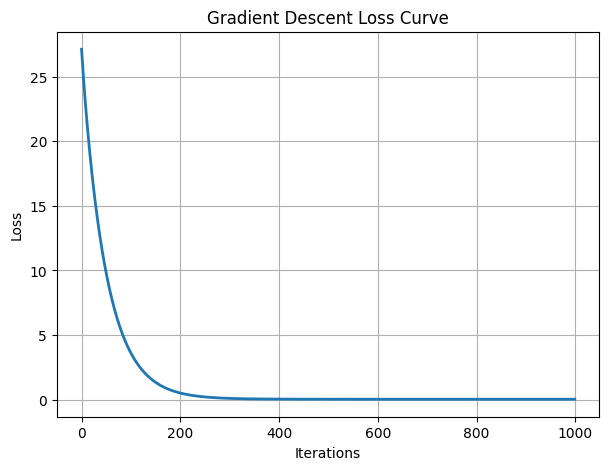

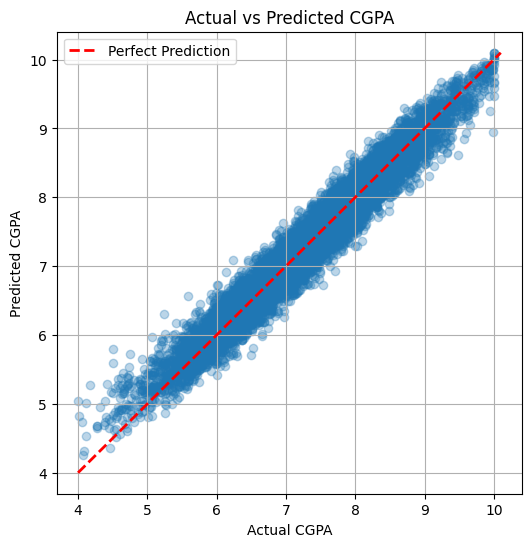


Loss graph saved successfully!

Program Completed Successfully!


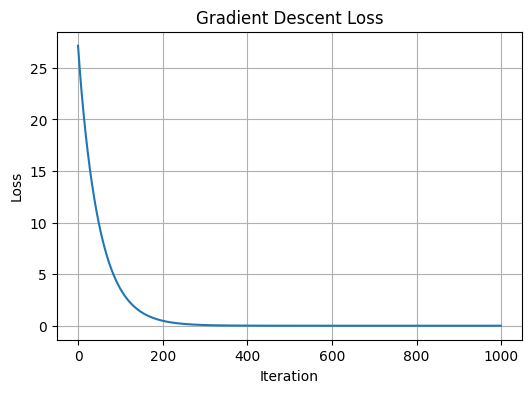

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# 1. Load Dataset
# ---------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/colab/placement_predict_50k_adjusted.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)
print(df.head())

# ---------------------------------------------------------
# 2. Select Features and Target
# ---------------------------------------------------------
target_col = "CGPA"

# Remove target and unwanted columns
sgpa_cols = [f"SGPA_Sem{i}" for i in range(1, 9)]

drop_cols = [
    c for c in [target_col, "StudentID", "CGPA_Tier"] + sgpa_cols
    if c in df.columns
]

feature_df = df.drop(columns=drop_cols)

# Keep only numeric columns
feature_df = feature_df.select_dtypes(include=[np.number])

# Fill missing values
feature_df = feature_df.fillna(feature_df.median())

X = feature_df.values
y = df[target_col].values.reshape(-1, 1)

print("\nNumber of Features:", X.shape[1])

# ---------------------------------------------------------
# 3. Train-Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ---------------------------------------------------------
# 4. Feature Scaling
# ---------------------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Add bias column
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# ---------------------------------------------------------
# 5. Gradient Descent Function
# ---------------------------------------------------------
def gradient_descent(X, y, learning_rate=0.01, iterations=1000):

    m, n = X.shape

    theta = np.zeros((n, 1))

    losses = []

    for i in range(iterations):

        predictions = X @ theta

        errors = predictions - y

        loss = np.mean(errors ** 2) / 2

        losses.append(loss)

        gradient = (X.T @ errors) / m

        theta = theta - learning_rate * gradient

        if i % 100 == 0:
            print(f"Iteration {i:4d} | Loss = {loss:.6f}")

    return theta, losses

# ---------------------------------------------------------
# 6. Train Model
# ---------------------------------------------------------
theta, losses = gradient_descent(
    X_train_b,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

# ---------------------------------------------------------
# 7. Prediction
# ---------------------------------------------------------
y_pred = X_test_b @ theta

# ---------------------------------------------------------
# 8. Evaluation
# ---------------------------------------------------------
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n===============================")
print("Gradient Descent Performance")
print("===============================")
print("Mean Squared Error :", mse)
print("R² Score           :", r2)

print("\nModel Parameters (Theta):")
print(theta.ravel())

# ---------------------------------------------------------
# 9. Compare with Scikit-Learn
# ---------------------------------------------------------
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

sk_predictions = lr_model.predict(X_test)

print("\n===============================")
print("Scikit-Learn Linear Regression")
print("===============================")
print("MSE :", mean_squared_error(y_test, sk_predictions))
print("R²  :", r2_score(y_test, sk_predictions))

# ---------------------------------------------------------
# 10. Loss Curve
# ---------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(losses, linewidth=2)
plt.title("Gradient Descent Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 11. Actual vs Predicted
# ---------------------------------------------------------
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    'r--',
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted CGPA")
plt.xlabel("Actual CGPA")
plt.ylabel("Predicted CGPA")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# 12. Save Plot
# ---------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("Gradient Descent Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)

plt.savefig("/content/drive/MyDrive/colab/gradient_descent_loss.png", dpi=300)

print("\nLoss graph saved successfully!")

print("\nProgram Completed Successfully!")